In [ ]:
import matplotlib
import matplotlib.cm

# Create a custom bridge function that catches the exact old arguments
def patched_register_cmap(name=None, cmap=None, **kwargs):
    # Pass them to the new Matplotlib system in the correct format
    matplotlib.colormaps.register(cmap=cmap, name=name)

# Apply the patch
matplotlib.cm.register_cmap = patched_register_cmap


In [ ]:
# numpy and pandas for data manipulation
import numpy as np
import pandas as pd

# sklearn preprocessing for dealing with categorical variables
from sklearn.preprocessing import LabelEncoder

# File system manangement
import os

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# matplotlib and seaborn for plotting
import matplotlib.pyplot as plt
import seaborn as sns

#We put all datasets in Google drive "My Drive", so here we have to prepare for data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
print(os.listdir("/content/input"))


FileNotFoundError: [Errno 2] No such file or directory: '/content/input'

In [ ]:
!mkdir -p /input
!ln -s "/content/drive/My Drive/home-credit-default-risk" /input/home-credit-default-risk

## Read in Data


In [ ]:
# List files available
print(os.listdir("../input/"))

['home-credit-default-risk']


In [ ]:
!ln -s "/content/drive/My Drive/home-credit-default-risk/"* /input/

ln: failed to create symbolic link '/input/home-credit-default-risk': File exists


In [ ]:
# Training data
app_train = pd.read_csv('../input/application_train.csv')
print('Training data shape: ', app_train.shape)
app_train.head()

Training data shape:  (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


The training data has 307511 observations (each one a separate loan) and 122 features (variables) including the `TARGET` (the label we want to predict).

In [ ]:
# Testing data features
app_test = pd.read_csv('../input/application_test.csv')
print('Testing data shape: ', app_test.shape)
app_test.head()

Testing data shape:  (48744, 121)


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


The test set is considerably smaller and lacks a `TARGET` column.

# Exploratory Data Analysis

## Examine the Distribution of the Target Column

The target is what we are asked to predict: either a 0 for the loan was repaid on time, or a 1 indicating the client had payment difficulties.

In [ ]:
app_train['TARGET'].value_counts()

,count
TARGET,
0,282686
1,24825


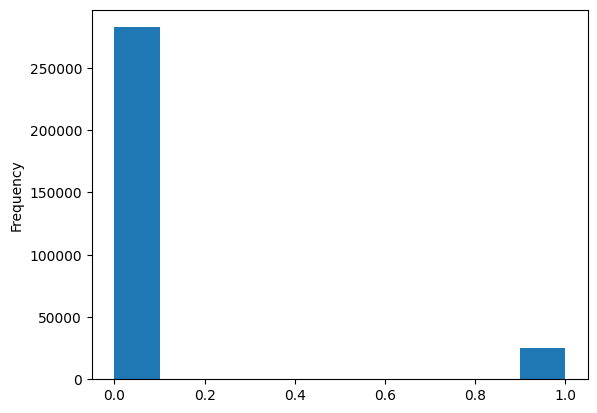

In [ ]:
app_train['TARGET'].astype(int).plot.hist();

From this information, we see this is an imbalanced class problem. There are far more loans that were repaid on time than loans that were not repaid.

## Examine Missing Values

Next we look at the number and percentage of missing values in each column.

In [ ]:
# Function to calculate missing values by column# Funct
def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()

        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)

        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})

        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)

        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")

        # Return the dataframe with missing information
        return mis_val_table_ren_columns

In [ ]:
# Missing values statistics
missing_values = missing_values_table(app_train)
missing_values.head(20)

Your selected dataframe has 122 columns.
There are 67 columns that have missing values.


,Missing Values,% of Total Values
COMMONAREA_MEDI,214865,69.9
COMMONAREA_MODE,214865,69.9
COMMONAREA_AVG,214865,69.9
NONLIVINGAPARTMENTS_MODE,213514,69.4
NONLIVINGAPARTMENTS_MEDI,213514,69.4
NONLIVINGAPARTMENTS_AVG,213514,69.4
FONDKAPREMONT_MODE,210295,68.4
LIVINGAPARTMENTS_AVG,210199,68.4
LIVINGAPARTMENTS_MEDI,210199,68.4
LIVINGAPARTMENTS_MODE,210199,68.4


## Column Types

In [ ]:
# Number of each type of column
app_train.dtypes.value_counts()

,count
float64,65
int64,41
object,16


In [ ]:
# Number of unique classes in each object column
app_train.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

,0
NAME_CONTRACT_TYPE,2
CODE_GENDER,3
FLAG_OWN_CAR,2
FLAG_OWN_REALTY,2
NAME_TYPE_SUITE,7
NAME_INCOME_TYPE,8
NAME_EDUCATION_TYPE,5
NAME_FAMILY_STATUS,6
NAME_HOUSING_TYPE,6
OCCUPATION_TYPE,18


## Encoding Categorical Variables

### Label Encoding and One-Hot Encoding

In [ ]:
# Create a label encoder object
le = LabelEncoder()
le_count = 0

# Iterate through the columns
for col in app_train:
    if app_train[col].dtype == 'object':
        # If 2 or fewer unique categories
        if len(list(app_train[col].unique())) <= 2:
            # Train on the training data
            le.fit(app_train[col])
            # Transform both training and testing data
            app_train[col] = le.transform(app_train[col])
            app_test[col] = le.transform(app_test[col])

            # Keep track of how many columns were label encoded
            le_count += 1

print('%d columns were label encoded.' % le_count)

3 columns were label encoded.


In [ ]:
# one-hot encoding of categorical variables
app_train = pd.get_dummies(app_train)
app_test = pd.get_dummies(app_test)

print('Training Features shape: ', app_train.shape)
print('Testing Features shape: ', app_test.shape)

Training Features shape:  (307511, 243)
Testing Features shape:  (48744, 239)


### Aligning Training and Testing Data

In [ ]:
train_labels = app_train['TARGET']

# Align the training and testing data, keep only columns present in both dataframes
app_train, app_test = app_train.align(app_test, join = 'inner', axis = 1)

# Add the target back in
app_train['TARGET'] = train_labels

print('Training Features shape: ', app_train.shape)
print('Testing Features shape: ', app_test.shape)

Training Features shape:  (307511, 240)
Testing Features shape:  (48744, 239)



### Anomalies


In [ ]:
(app_train['DAYS_BIRTH'] / -365).describe()

,DAYS_BIRTH
count,307511.000000
mean,43.936973
std,11.956133
min,20.517808
25%,34.008219
50%,43.150685
75%,53.923288
max,69.120548


Those ages look reasonable. There are no outliers for the age on either the high or low end.

In [ ]:
app_train['DAYS_EMPLOYED'].describe()

,DAYS_EMPLOYED
count,307511.000000
mean,63815.045904
std,141275.766519
min,-17912.000000
25%,-2760.000000
50%,-1213.000000
75%,-289.000000
max,365243.000000


That doesn't look right! The maximum value (besides being positive) is about 1000 years!

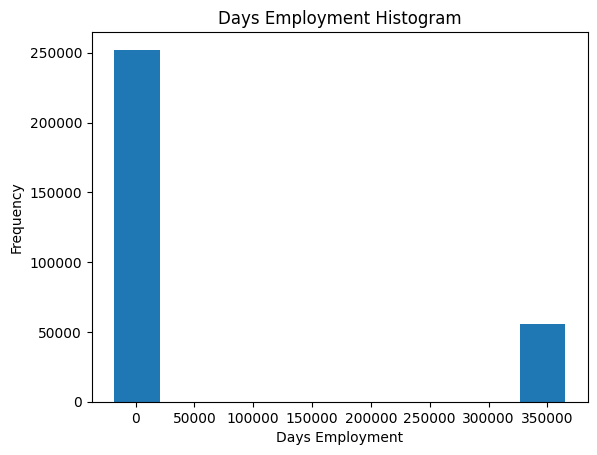

In [ ]:
app_train['DAYS_EMPLOYED'].plot.hist(title = 'Days Employment Histogram');
plt.xlabel('Days Employment');

In [ ]:
anom = app_train[app_train['DAYS_EMPLOYED'] == 365243]
non_anom = app_train[app_train['DAYS_EMPLOYED'] != 365243]
print('The non-anomalies default on %0.2f%% of loans' % (100 * non_anom['TARGET'].mean()))
print('The anomalies default on %0.2f%% of loans' % (100 * anom['TARGET'].mean()))
print('There are %d anomalous days of employment' % len(anom))

The non-anomalies default on 8.66% of loans
The anomalies default on 5.40% of loans
There are 55374 anomalous days of employment


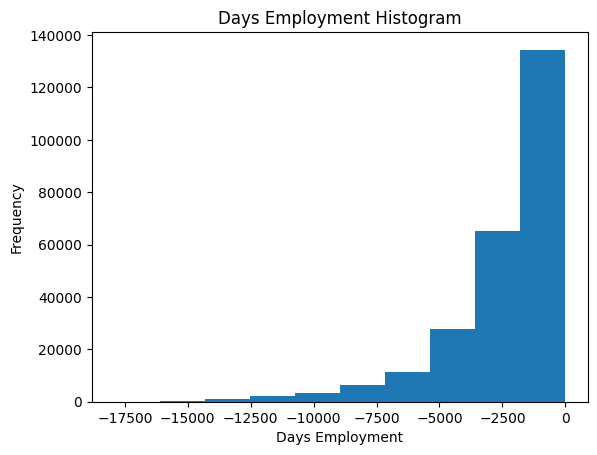

In [ ]:
# Create an anomalous flag column
app_train['DAYS_EMPLOYED_ANOM'] = app_train["DAYS_EMPLOYED"] == 365243

# Replace the anomalous values with nan
app_train['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace = True)

app_train['DAYS_EMPLOYED'].plot.hist(title = 'Days Employment Histogram');
plt.xlabel('Days Employment');

In [ ]:
app_test['DAYS_EMPLOYED_ANOM'] = app_test["DAYS_EMPLOYED"] == 365243
app_test["DAYS_EMPLOYED"].replace({365243: np.nan}, inplace = True)

print('There are %d anomalies in the test data out of %d entries' % (app_test["DAYS_EMPLOYED_ANOM"].sum(), len(app_test)))

There are 9274 anomalies in the test data out of 48744 entries


### Correlations

In [ ]:
# Find correlations with the target and sort
correlations = app_train.corr()['TARGET'].sort_values()

# Display correlations
print('Most Positive Correlations:\n', correlations.tail(15))
print('\nMost Negative Correlations:\n', correlations.head(15))

Most Positive Correlations:
 OCCUPATION_TYPE_Laborers                             0.043019
FLAG_DOCUMENT_3                                      0.044346
REG_CITY_NOT_LIVE_CITY                               0.044395
FLAG_EMP_PHONE                                       0.045982
NAME_EDUCATION_TYPE_Secondary / secondary special    0.049824
REG_CITY_NOT_WORK_CITY                               0.050994
DAYS_ID_PUBLISH                                      0.051457
CODE_GENDER_M                                        0.054713
DAYS_LAST_PHONE_CHANGE                               0.055218
NAME_INCOME_TYPE_Working                             0.057481
REGION_RATING_CLIENT                                 0.058899
REGION_RATING_CLIENT_W_CITY                          0.060893
DAYS_EMPLOYED                                        0.074958
DAYS_BIRTH                                           0.078239
TARGET                                               1.000000
Name: TARGET, dtype: float64

Most Negati

### Effect of Age on Repayment

In [ ]:
# Find the correlation of the positive days since birth and target
app_train['DAYS_BIRTH'] = abs(app_train['DAYS_BIRTH'])
app_train['DAYS_BIRTH'].corr(app_train['TARGET'])

np.float64(-0.07823930830982692)

As the client gets older, there is a negative linear relationship with the target meaning that as clients get older, they tend to repay their loans on time more often.

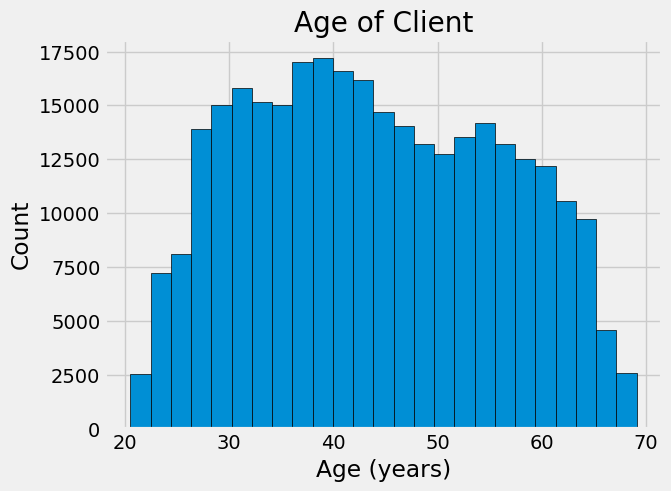

In [ ]:
# Set the style of plots
plt.style.use('fivethirtyeight')

# Plot the distribution of ages in years
plt.hist(app_train['DAYS_BIRTH'] / 365, edgecolor = 'k', bins = 25)
plt.title('Age of Client'); plt.xlabel('Age (years)'); plt.ylabel('Count');

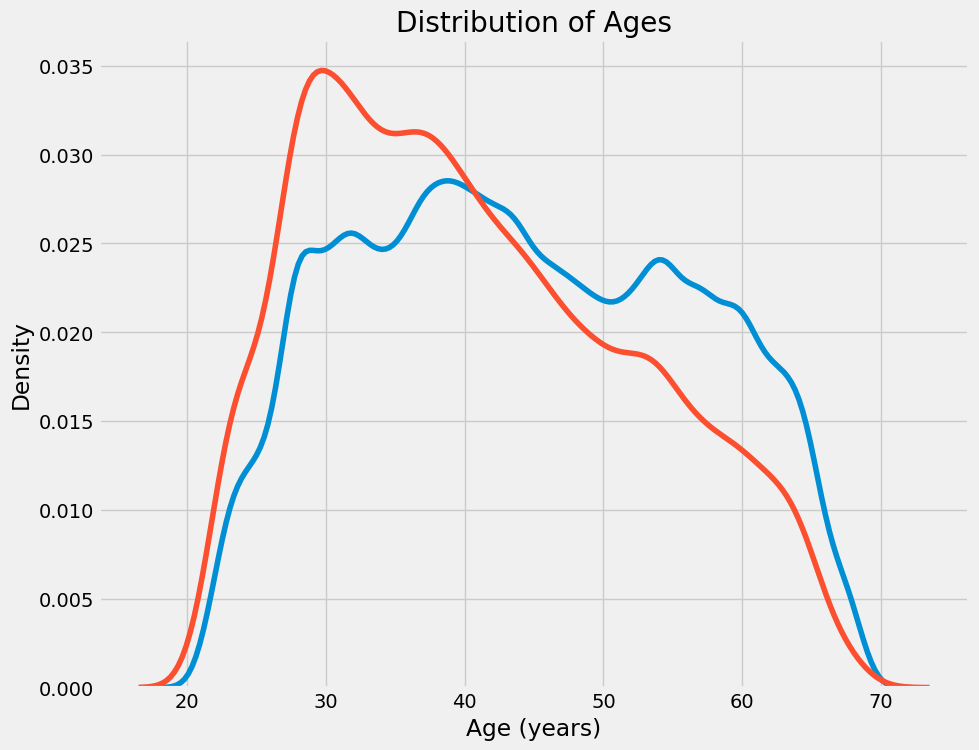

In [ ]:
plt.figure(figsize = (10, 8))

# KDE plot of loans that were repaid on time
sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, 'DAYS_BIRTH'] / 365, label = 'target == 0')

# KDE plot of loans which were not repaid on time
sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, 'DAYS_BIRTH'] / 365, label = 'target == 1')

# Labeling of plot
plt.xlabel('Age (years)'); plt.ylabel('Density'); plt.title('Distribution of Ages');

The target == 1 curve skews towards the younger end of the range. Although this is not a significant correlation (-0.07 correlation coefficient), this variable is likely going to be useful in a machine learning model because it does affect the target.

In [ ]:
# Age information into a separate dataframe
age_data = app_train[['TARGET', 'DAYS_BIRTH']]
age_data['YEARS_BIRTH'] = age_data['DAYS_BIRTH'] / 365

# Bin the age data
age_data['YEARS_BINNED'] = pd.cut(age_data['YEARS_BIRTH'], bins = np.linspace(20, 70, num = 11))
age_data.head(10)

,TARGET,DAYS_BIRTH,YEARS_BIRTH,YEARS_BINNED
0,1,9461,25.920548,"(25.0, 30.0]"
1,0,16765,45.931507,"(45.0, 50.0]"
2,0,19046,52.180822,"(50.0, 55.0]"
3,0,19005,52.068493,"(50.0, 55.0]"
4,0,19932,54.608219,"(50.0, 55.0]"
5,0,16941,46.413699,"(45.0, 50.0]"
6,0,13778,37.747945,"(35.0, 40.0]"
7,0,18850,51.643836,"(50.0, 55.0]"
8,0,20099,55.065753,"(55.0, 60.0]"
9,0,14469,39.641096,"(35.0, 40.0]"


In [ ]:
# Group by the bin and calculate averages
age_groups  = age_data.groupby('YEARS_BINNED').mean()
age_groups

,TARGET,DAYS_BIRTH,YEARS_BIRTH
YEARS_BINNED,,,
"(20.0, 25.0]",0.123036,8532.795625,23.377522
"(25.0, 30.0]",0.111436,10155.219250,27.822518
"(30.0, 35.0]",0.102814,11854.848377,32.479037
"(35.0, 40.0]",0.089414,13707.908253,37.555913
"(40.0, 45.0]",0.078491,15497.661233,42.459346
"(45.0, 50.0]",0.074171,17323.900441,47.462741
"(50.0, 55.0]",0.066968,19196.494791,52.593136
"(55.0, 60.0]",0.055314,20984.262742,57.491131
"(60.0, 65.0]",0.052737,22780.547460,62.412459


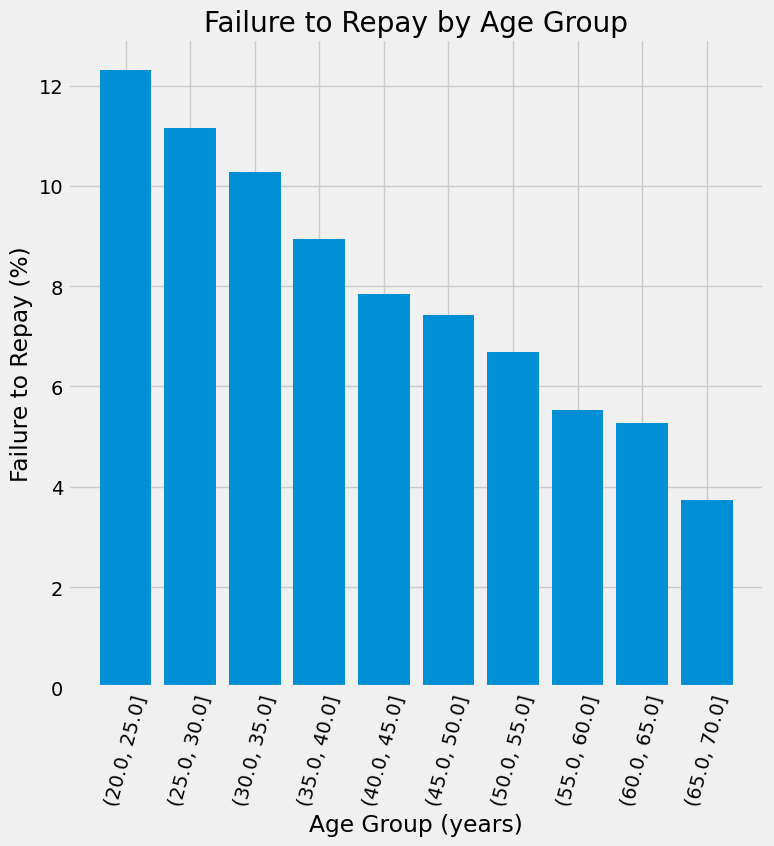

In [ ]:
plt.figure(figsize = (8, 8))

# Graph the age bins and the average of the target as a bar plot
plt.bar(age_groups.index.astype(str), 100 * age_groups['TARGET'])

# Plot labeling
plt.xticks(rotation = 75); plt.xlabel('Age Group (years)'); plt.ylabel('Failure to Repay (%)')
plt.title('Failure to Repay by Age Group');

There is a clear trend: younger applicants are more likely to not repay the loan The rate of failure to repay is above 10% for the youngest three age groups and beolow 5% for the oldest age group.

This is information that could be directly used by the bank: because younger clients are less likely to repay the loan, maybe they should be provided with more guidance or financial planning tips. This does not mean the bank should discriminate against younger clients, but it would be smart to take precautionary measures to help younger clients pay on time.

### Exterior Sources

The 3 variables with the strongest negative correlations with the target are `EXT_SOURCE_1`, `EXT_SOURCE_2`, and `EXT_SOURCE_3`.
According to the documentation, these features represent a "normalized score from external data source". I'm not sure what this exactly means, but it may be a cumulative sort of credit rating made using numerous sources of data.

Let's take a look at these variables.

First, we can show the correlations of the `EXT_SOURCE` features with the target and with each other.

In [ ]:
# Extract the EXT_SOURCE variables and show correlations
ext_data = app_train[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]
ext_data_corrs = ext_data.corr()
ext_data_corrs

,TARGET,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH
TARGET,1.000000,-0.155317,-0.160472,-0.178919,-0.078239
EXT_SOURCE_1,-0.155317,1.000000,0.213982,0.186846,0.600610
EXT_SOURCE_2,-0.160472,0.213982,1.000000,0.109167,0.091996
EXT_SOURCE_3,-0.178919,0.186846,0.109167,1.000000,0.205478
DAYS_BIRTH,-0.078239,0.600610,0.091996,0.205478,1.000000


In [ ]:
!pip install --upgrade seaborn

In [ ]:
import seaborn as sns
import functools

# Save the modern, working PairGrid
original_pairgrid = sns.PairGrid

# Create a bridge that intercepts 'size' and translates it to 'height' for modern seaborn
@functools.wraps(original_pairgrid)
def patched_pairgrid(*args, **kwargs):
    if 'size' in kwargs:
        kwargs['height'] = kwargs.pop('size')
    return original_pairgrid(*args, **kwargs)

# Apply the patch silently
sns.PairGrid = patched_pairgrid

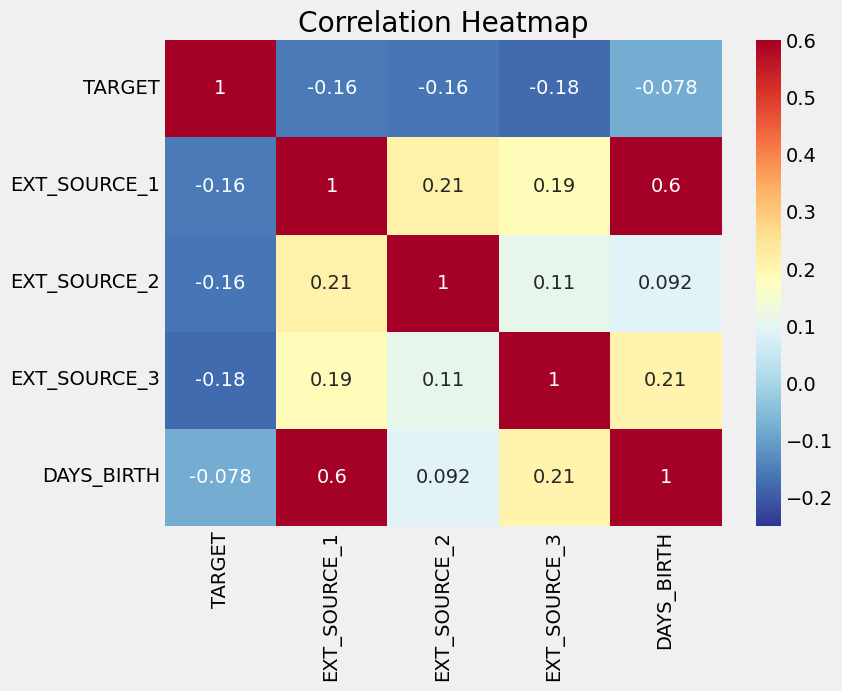

In [ ]:
plt.figure(figsize = (8, 6))

# Heatmap of correlations
sns.heatmap(ext_data_corrs, cmap = plt.cm.RdYlBu_r, vmin = -0.25, annot = True, vmax = 0.6)
plt.title('Correlation Heatmap');

All three `EXT_SOURCE` featureshave negative correlations with the target, indicating that as the value of the `EXT_SOURCE` increases, the client is more likely to repay the loan. We can also see that `DAYS_BIRTH` is positively correlated with `EXT_SOURCE_1` indicating that maybe one of the factors in this score is the client age.

Next we can look at the distribution of each of these features colored by the value of the target. This will let us visualize the effect of this variable on the target.

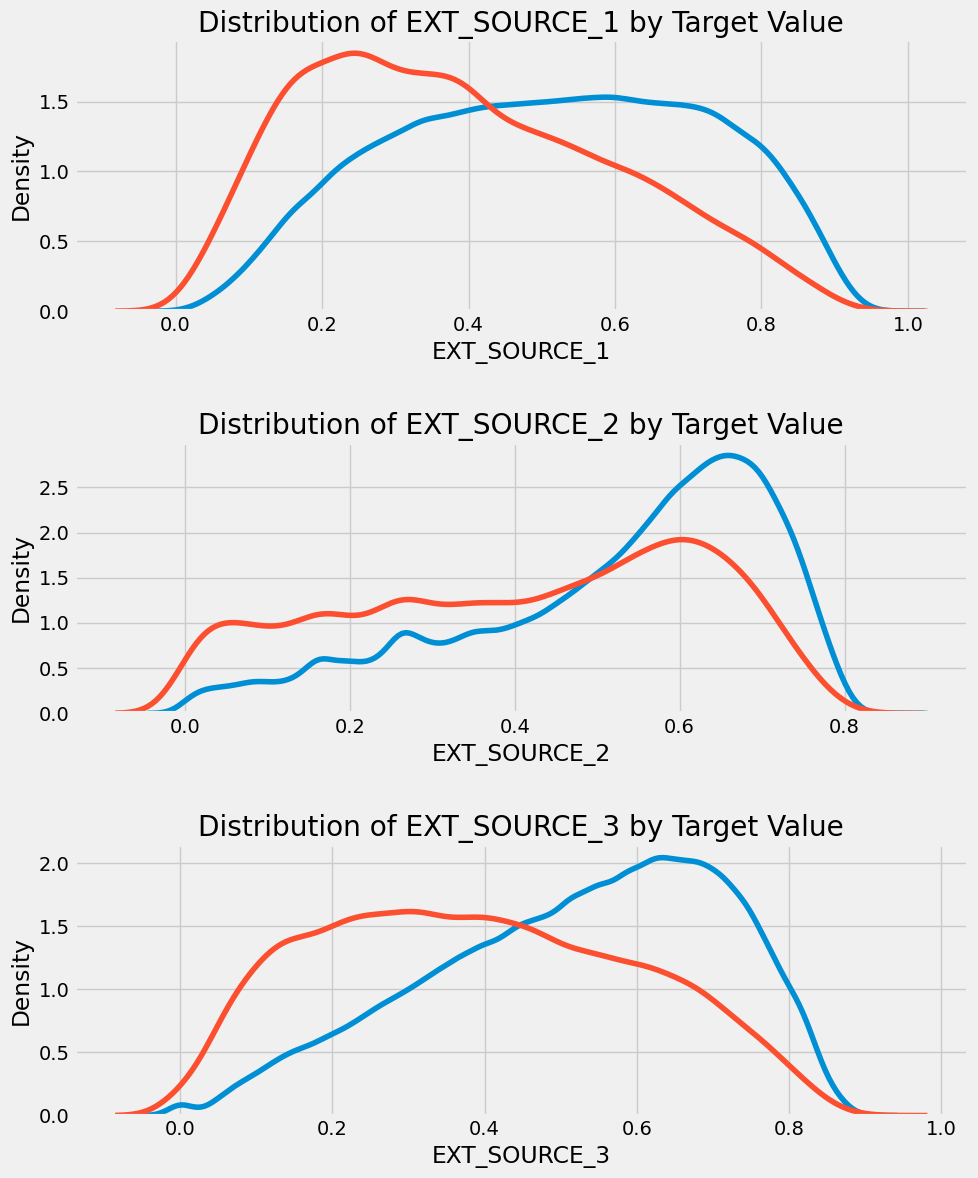

In [ ]:
plt.figure(figsize = (10, 12))

# iterate through the sources
for i, source in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):

    # create a new subplot for each source
    plt.subplot(3, 1, i + 1)
    # plot repaid loans
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, source], label = 'target == 0')
    # plot loans that were not repaid
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, source], label = 'target == 1')

    # Label the plots
    plt.title('Distribution of %s by Target Value' % source)
    plt.xlabel('%s' % source); plt.ylabel('Density');

plt.tight_layout(h_pad = 2.5)


## Pairs Plot


In [ ]:
import seaborn as sns
import functools

# Safety check so we don't double-patch
if not hasattr(sns.kdeplot, "_is_patched_for_norm"):
    _original_kdeplot = sns.kdeplot

    @functools.wraps(_original_kdeplot)
    def patched_kdeplot(*args, **kwargs):
        # Force modern seaborn to normalize groups independently like old seaborn did
        if 'common_norm' not in kwargs:
            kwargs['common_norm'] = False
        return _original_kdeplot(*args, **kwargs)

    # Mark as patched and apply
    patched_kdeplot._is_patched_for_norm = True
    sns.kdeplot = patched_kdeplot


# Baseline

Validation ROC-AUC: 0.6876300647387847


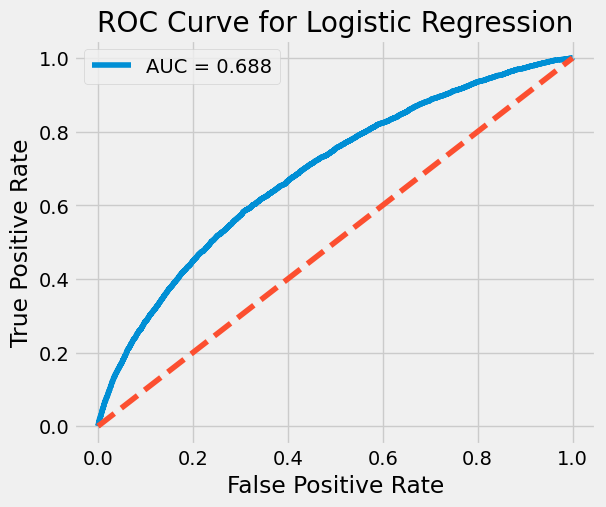

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Separate features and labels
X = app_train.drop(columns=['TARGET'])
y = app_train['TARGET']

# 2. Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Impute missing values
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_val_imputed = imputer.transform(X_val)

# 4. Scale features
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)

# 5. Train logistic regression
log_reg = LogisticRegression(C=0.0001, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# 6. Predict probabilities on validation set
y_val_pred_prob = log_reg.predict_proba(X_val_scaled)[:, 1]

# 7. Compute ROC-AUC
auc = roc_auc_score(y_val, y_val_pred_prob)
print("Validation ROC-AUC:", auc)

# 8. Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_val_pred_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression")
plt.legend()
plt.show()

Training data shape: (246008, 240)
Validation data shape: (61503, 240)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 48 concurrent workers.


                   feature  importance
32            EXT_SOURCE_2    0.049213
33            EXT_SOURCE_3    0.045821
10              DAYS_BIRTH    0.032213
13         DAYS_ID_PUBLISH    0.031846
12       DAYS_REGISTRATION    0.031281
0               SK_ID_CURR    0.030496
11           DAYS_EMPLOYED    0.029126
7              AMT_ANNUITY    0.028903
81  DAYS_LAST_PHONE_CHANGE    0.027947
6               AMT_CREDIT    0.027253
Validation ROC-AUC: 0.7061381846686043


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    3.2s finished
[Parallel(n_jobs=48)]: Using backend ThreadingBackend with 48 concurrent workers.
[Parallel(n_jobs=48)]: Done 100 out of 100 | elapsed:    0.1s finished


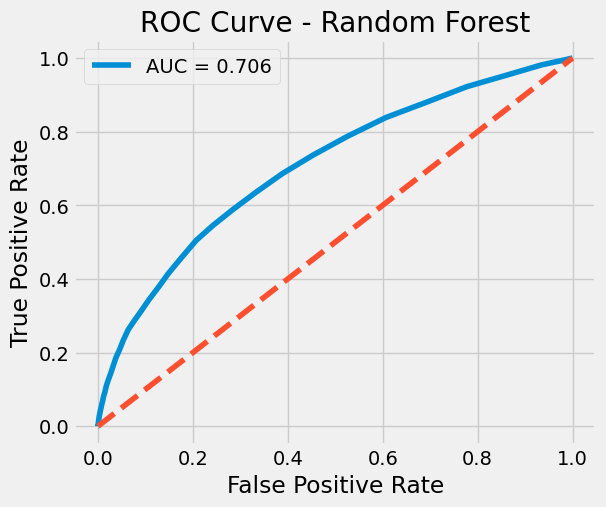

In [ ]:
from sklearn.ensemble import RandomForestClassifier

X = app_train.drop(columns=['TARGET'])
y = app_train['TARGET']

features = list(X.columns)

X_train_df, X_val_df, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

imputer = SimpleImputer(strategy='median')

X_train = imputer.fit_transform(X_train_df)
X_val = imputer.transform(X_val_df)

scaler = MinMaxScaler(feature_range=(0, 1))

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

print('Training data shape:', X_train.shape)
print('Validation data shape:', X_val.shape)

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=50,
    verbose=1,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)


feature_importance_values = random_forest.feature_importances_
feature_importances = pd.DataFrame({
    'feature': features,
    'importance': feature_importance_values
}).sort_values('importance', ascending=False)

print(feature_importances.head(10))

y_val_pred_prob = random_forest.predict_proba(X_val)[:, 1]

auc = roc_auc_score(y_val, y_val_pred_prob)
print("Validation ROC-AUC:", auc)

fpr, tpr, thresholds = roc_curve(y_val, y_val_pred_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

# Part 4: Auditing & Outcome

## 4a. Accuracy across subpopulations

In [ ]:
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)

In [ ]:
print(y_val.mean())
thresholds = [0.5, 0.2, y_val.mean()]
audit_df = X_val_df.copy()
audit_df["y_true"] = y_val
audit_df["y_prob"] = y_val_pred_prob

0.08072776937710356


Since the dataset is highly imbalanced, a threshold of 0.5 may be overly conservative. We additionally consider additional thresholds of 0.2 and the empirical default rate.

In [ ]:
def compute_group_metrics(df):
    y_true = df["y_true"]
    y_pred = df["y_pred"]
    y_prob = df["y_prob"]

    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()

    if y_true.nunique() == 2:
        auc = roc_auc_score(y_true, y_prob)
    else:
        auc = np.nan

    return pd.Series({
        "n": len(df),
        "true_default_rate": y_true.mean(),
        "predicted_default_rate": y_pred.mean(),
        "ROC_AUC": auc,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "FPR": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
        "FNR": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

In [ ]:
def subgroup_audit(audit_df, threshold):

    audit_df = audit_df.copy()

    audit_df["y_pred"] = (
        audit_df["y_prob"] >= threshold
    ).astype(int)

    audit_df["AGE"] = (audit_df["DAYS_BIRTH"] / 365).astype(int)

    audit_df["AGE_GROUP"] = pd.cut(
        audit_df["AGE"],
        bins=[20, 30, 40, 50, 60, 70],
        labels=["20-30", "30-40", "40-50", "50-60", "60-70"],
        include_lowest=True
    )

    audit_df["INCOME_GROUP"] = pd.qcut(
        audit_df["AMT_INCOME_TOTAL"],
        q=4,
        labels=["Q1_lowest", "Q2", "Q3", "Q4_highest"],
        duplicates="drop"
    )

    gender_results = audit_df.groupby(
        "CODE_GENDER_F",
        observed=True
    ).apply(compute_group_metrics)

    age_results = audit_df.groupby(
        "AGE_GROUP",
        observed=True
    ).apply(compute_group_metrics)

    income_results = audit_df.groupby(
        "INCOME_GROUP",
        observed=True
    ).apply(compute_group_metrics)

    return gender_results, age_results, income_results

Threshold: 0.5
                     n  true_default_rate  predicted_default_rate  ROC_AUC  \
CODE_GENDER_F                                                                
False          20942.0              0.102                     0.0    0.707   
True           40561.0              0.070                     0.0    0.696   

               Accuracy  Precision  Recall     F1  FPR    FNR       TN   FP  \
CODE_GENDER_F                                                                 
False             0.898      0.667   0.001  0.002  0.0  0.999  18812.0  1.0   
True              0.930      0.875   0.002  0.005  0.0  0.998  37724.0  1.0   

                   FN   TP  
CODE_GENDER_F               
False          2127.0  2.0  
True           2829.0  7.0  


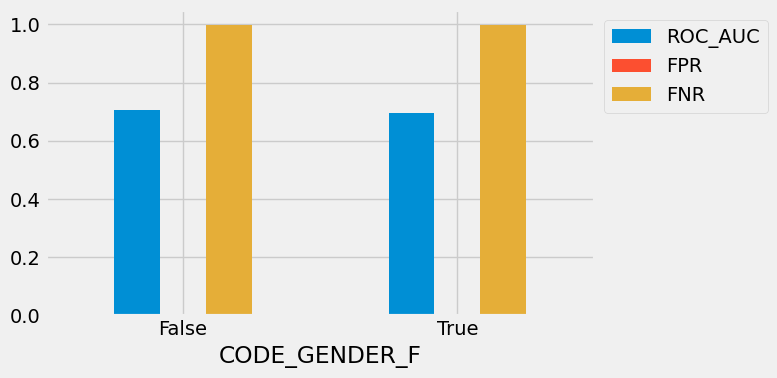

                 n  true_default_rate  predicted_default_rate  ROC_AUC  \
AGE_GROUP                                                                
20-30      10465.0              0.114                   0.001    0.686   
30-40      16570.0              0.092                   0.000    0.705   
40-50      14870.0              0.076                   0.000    0.708   
50-60      13610.0              0.060                   0.000    0.684   
60-70       5988.0              0.051                   0.000    0.634   

           Accuracy  Precision  Recall     F1  FPR    FNR       TN   FP  \
AGE_GROUP                                                                 
20-30         0.887      1.000   0.006  0.012  0.0  0.994   9276.0  0.0   
30-40         0.908      0.667   0.001  0.003  0.0  0.999  15051.0  1.0   
40-50         0.924      0.000   0.000  0.000  0.0  1.000  13735.0  1.0   
50-60         0.940      0.000   0.000  0.000  0.0  1.000  12791.0  0.0   
60-70         0.949      0.000 

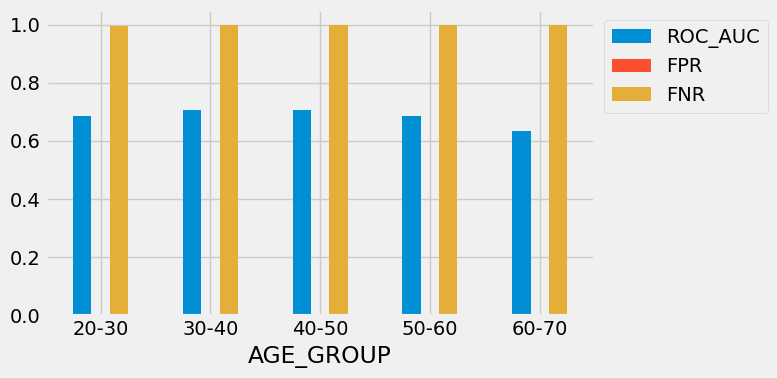

                    n  true_default_rate  predicted_default_rate  ROC_AUC  \
INCOME_GROUP                                                                
Q1_lowest     20075.0              0.082                     0.0    0.706   
Q2            10678.0              0.086                     0.0    0.707   
Q3            16356.0              0.085                     0.0    0.696   
Q4_highest    14394.0              0.071                     0.0    0.717   

              Accuracy  Precision  Recall     F1  FPR    FNR       TN   FP  \
INCOME_GROUP                                                                 
Q1_lowest        0.918      0.667   0.002  0.005  0.0  0.998  18431.0  2.0   
Q2               0.914      1.000   0.004  0.009  0.0  0.996   9757.0  0.0   
Q3               0.915      1.000   0.001  0.001  0.0  0.999  14969.0  0.0   
Q4_highest       0.929      0.000   0.000  0.000  0.0  1.000  13379.0  0.0   

                  FN   TP  
INCOME_GROUP               
Q1_lowest   

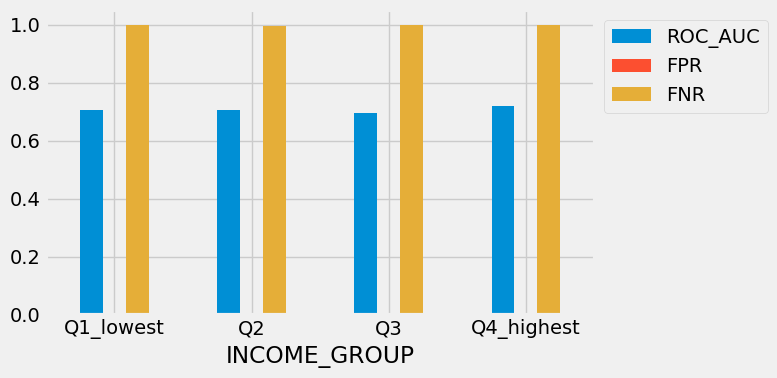


Threshold: 0.2
                     n  true_default_rate  predicted_default_rate  ROC_AUC  \
CODE_GENDER_F                                                                
False          20942.0              0.102                   0.118    0.707   
True           40561.0              0.070                   0.060    0.696   

               Accuracy  Precision  Recall     F1    FPR    FNR       TN  \
CODE_GENDER_F                                                              
False             0.848      0.285   0.332  0.307  0.094  0.668  17044.0   
True              0.900      0.245   0.210  0.226  0.049  0.790  35893.0   

                   FP      FN     TP  
CODE_GENDER_F                         
False          1769.0  1423.0  706.0  
True           1832.0  2240.0  596.0  


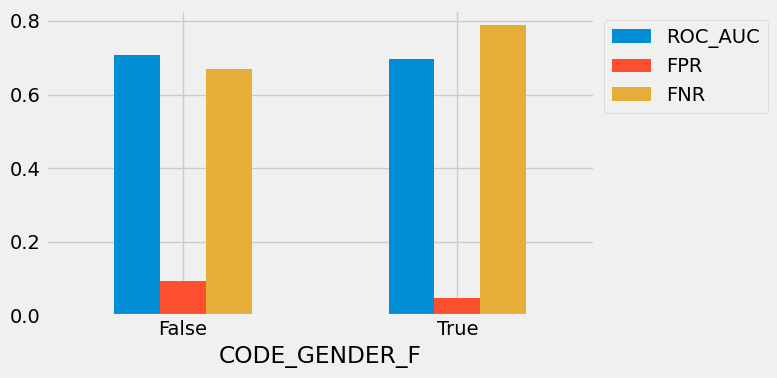

                 n  true_default_rate  predicted_default_rate  ROC_AUC  \
AGE_GROUP                                                                
20-30      10465.0              0.114                   0.177    0.686   
30-40      16570.0              0.092                   0.096    0.705   
40-50      14870.0              0.076                   0.061    0.708   
50-60      13610.0              0.060                   0.033    0.684   
60-70       5988.0              0.051                   0.018    0.634   

           Accuracy  Precision  Recall     F1    FPR    FNR       TN      FP  \
AGE_GROUP                                                                      
20-30         0.797      0.248   0.387  0.302  0.151  0.613   7879.0  1397.0   
30-40         0.865      0.275   0.287  0.281  0.076  0.713  13905.0  1147.0   
40-50         0.899      0.298   0.238  0.265  0.046  0.762  13100.0   636.0   
50-60         0.923      0.246   0.136  0.175  0.027  0.864  12450.0   341.0   
6

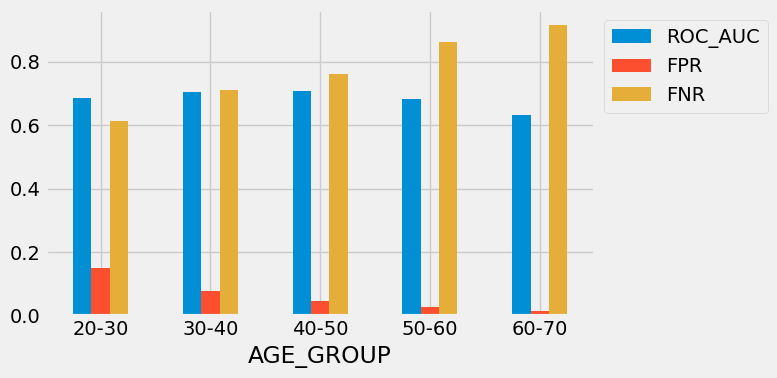

                    n  true_default_rate  predicted_default_rate  ROC_AUC  \
INCOME_GROUP                                                                
Q1_lowest     20075.0              0.082                   0.085    0.706   
Q2            10678.0              0.086                   0.090    0.707   
Q3            16356.0              0.085                   0.081    0.696   
Q4_highest    14394.0              0.071                   0.063    0.717   

              Accuracy  Precision  Recall     F1    FPR    FNR       TN  \
INCOME_GROUP                                                              
Q1_lowest        0.877      0.261   0.272  0.266  0.069  0.728  17167.0   
Q2               0.870      0.257   0.269  0.263  0.073  0.731   9041.0   
Q3               0.878      0.267   0.254  0.260  0.065  0.746  14003.0   
Q4_highest       0.902      0.282   0.252  0.266  0.049  0.748  12726.0   

                  FP      FN     TP  
INCOME_GROUP                         
Q1_lowest 

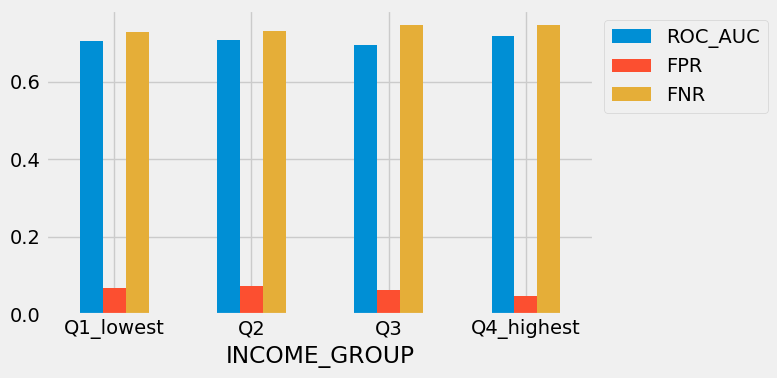


Threshold: 0.08072776937710356
                     n  true_default_rate  predicted_default_rate  ROC_AUC  \
CODE_GENDER_F                                                                
False          20942.0              0.102                   0.529    0.707   
True           40561.0              0.070                   0.352    0.696   

               Accuracy  Precision  Recall     F1    FPR    FNR       TN  \
CODE_GENDER_F                                                              
False             0.526      0.148   0.771  0.249  0.501  0.229   9380.0   
True              0.665      0.123   0.622  0.206  0.332  0.378  25206.0   

                    FP      FN      TP  
CODE_GENDER_F                           
False           9433.0   487.0  1642.0  
True           12519.0  1073.0  1763.0  


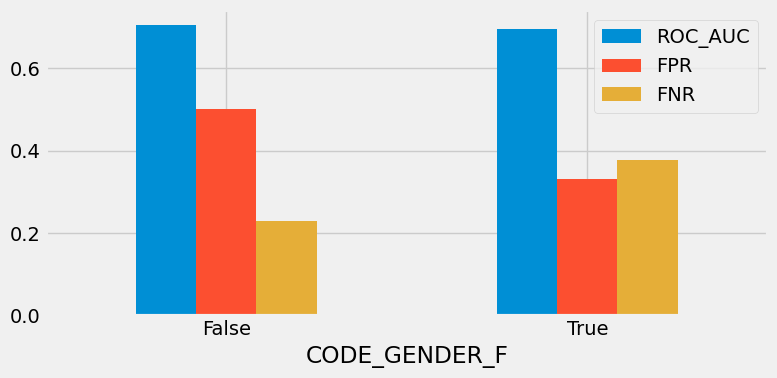

                 n  true_default_rate  predicted_default_rate  ROC_AUC  \
AGE_GROUP                                                                
20-30      10465.0              0.114                   0.640    0.686   
30-40      16570.0              0.092                   0.475    0.705   
40-50      14870.0              0.076                   0.377    0.708   
50-60      13610.0              0.060                   0.281    0.684   
60-70       5988.0              0.051                   0.227    0.634   

           Accuracy  Precision  Recall     F1    FPR    FNR      TN      FP  \
AGE_GROUP                                                                     
20-30         0.437      0.149   0.838  0.253  0.615  0.162  3572.0  5704.0   
30-40         0.567      0.141   0.731  0.236  0.450  0.269  8283.0  6769.0   
40-50         0.647      0.132   0.654  0.220  0.354  0.346  8878.0  4858.0   
50-60         0.724      0.115   0.537  0.190  0.264  0.463  9411.0  3380.0   
60-70  

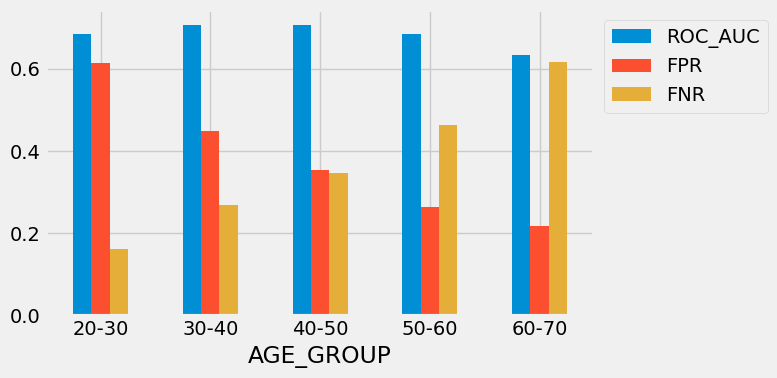

                    n  true_default_rate  predicted_default_rate  ROC_AUC  \
INCOME_GROUP                                                                
Q1_lowest     20075.0              0.082                   0.424    0.706   
Q2            10678.0              0.086                   0.425    0.707   
Q3            16356.0              0.085                   0.412    0.696   
Q4_highest    14394.0              0.071                   0.388    0.717   

              Accuracy  Precision  Recall     F1    FPR    FNR       TN  \
INCOME_GROUP                                                              
Q1_lowest        0.609      0.135   0.698  0.226  0.399  0.302  11071.0   
Q2               0.610      0.143   0.702  0.237  0.398  0.298   5870.0   
Q3               0.616      0.137   0.664  0.227  0.388  0.336   9157.0   
Q4_highest       0.638      0.124   0.681  0.209  0.366  0.319   8488.0   

                  FP     FN      TP  
INCOME_GROUP                         
Q1_lowest 

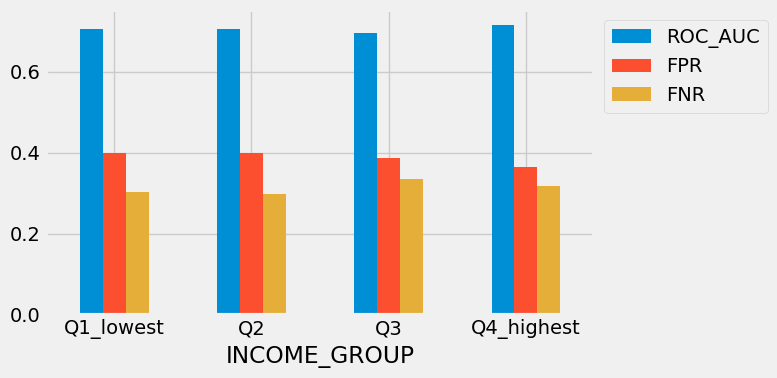

In [ ]:
for t in thresholds:

    gender_results, age_results, income_results = subgroup_audit(
        audit_df,
        threshold=t
    )

    print(f"Threshold: {t}")
    print(gender_results.round(3))

    gender_results[["ROC_AUC", "FPR", "FNR"]].plot.bar(figsize=(8,4))
    plt.legend(bbox_to_anchor=(1, 1))

    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

    print(age_results.round(3))

    age_results[["ROC_AUC", "FPR", "FNR"]].plot.bar(figsize=(8,4))
    plt.legend(bbox_to_anchor=(1, 1))

    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

    print(income_results.round(3))

    income_results[["ROC_AUC", "FPR", "FNR"]].plot.bar(figsize=(8,4))
    plt.legend(bbox_to_anchor=(1, 1))

    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()
    print()

## 4b Fairness metrics

In [ ]:
!pip install fairlearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 31.0 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [ ]:
from fairlearn.metrics import (
    demographic_parity_difference,
    equalized_odds_difference,
    equal_opportunity_difference,
    demographic_parity_ratio
)

In [ ]:
audit_df = X_val_df.copy()

audit_df["y_true"] = y_val
audit_df["y_prob"] = y_val_pred_prob

gender = audit_df["CODE_GENDER_F"]

threshold = [0.2, y_val.mean()]

In [ ]:
for t in threshold:
  audit_df["y_pred"] = (audit_df["y_prob"] >= t).astype(int)
  print(f"Threshold: {t}")
  dp_diff = demographic_parity_difference(
      y_true=audit_df["y_true"],
      y_pred=audit_df["y_pred"],
      sensitive_features=gender
  )

  print("Demographic Parity Difference:", dp_diff)

  eo_diff = equal_opportunity_difference(
    y_true=audit_df["y_true"],
    y_pred=audit_df["y_pred"],
    sensitive_features=gender
  )

  print("Equal Opportunity Difference:", eo_diff)

  eod_diff = equalized_odds_difference(
    y_true=audit_df["y_true"],
    y_pred=audit_df["y_pred"],
    sensitive_features=gender
  )

  print("Equalized Odds Difference:", eod_diff)

  dp_ratio = demographic_parity_ratio(
      y_true=audit_df["y_true"],
      y_pred=audit_df["y_pred"],
      sensitive_features=gender
  )

  print("Demographic Parity Ratio:", dp_ratio)


Threshold: 0.2
Demographic Parity Difference: 0.058323097489992044
Equal Opportunity Difference: 0.12145593692052992
Equalized Odds Difference: 0.12145593692052992
Demographic Parity Ratio: 0.5065041181271057
Threshold: 0.08072776937710356
Demographic Parity Difference: 0.17672992808192478
Equal Opportunity Difference: 0.14960389834517096
Equalized Odds Difference: 0.16955969387523256
Demographic Parity Ratio: 0.6658168709804362


In [ ]:
audit_df = X_val_df.copy()

audit_df["AGE"] = (audit_df["DAYS_BIRTH"] / 365).astype(int)

audit_df["AGE_GROUP"] = pd.cut(
        audit_df["AGE"],
        bins=[20, 30, 40, 50, 60, 70],
        labels=["20-30", "30-40", "40-50", "50-60", "60-70"],
        include_lowest=True
    )
audit_df["y_true"] = y_val
audit_df["y_prob"] = y_val_pred_prob

age = audit_df["AGE_GROUP"]

for t in threshold:
  audit_df["y_pred"] = (audit_df["y_prob"] >= t).astype(int)
  print(f"Threshold: {t}")
  dp_diff = demographic_parity_difference(
      y_true=audit_df["y_true"],
      y_pred=audit_df["y_pred"],
      sensitive_features=age
  )

  print("Demographic Parity Difference:", dp_diff)

  eo_diff = equal_opportunity_difference(
    y_true=audit_df["y_true"],
    y_pred=audit_df["y_pred"],
    sensitive_features=age
  )

  print("Equal Opportunity Difference:", eo_diff)

  eod_diff = equalized_odds_difference(
    y_true=audit_df["y_true"],
    y_pred=audit_df["y_pred"],
    sensitive_features=age
  )

  print("Equalized Odds Difference:", eod_diff)

  dp_ratio = demographic_parity_ratio(
      y_true=audit_df["y_true"],
      y_pred=audit_df["y_pred"],
      sensitive_features=age
  )

  print("Demographic Parity Ratio:", dp_ratio)

Threshold: 0.2
Demographic Parity Difference: 0.159913568177923
Equal Opportunity Difference: 0.3049125177515201
Equalized Odds Difference: 0.3049125177515201
Demographic Parity Ratio: 0.09881772160368124
Threshold: 0.08072776937710356
Demographic Parity Difference: 0.41344242873388115
Equal Opportunity Difference: 0.4540721642377532
Equalized Odds Difference: 0.4540721642377532
Demographic Parity Ratio: 0.3542276094477512


## 4c Additional audits

### SHAP interpretability

In [ ]:
!pip install shap
import shap

In [ ]:
X_val_shap = pd.DataFrame(
    X_val,
    columns=features
)

X_val_sample = X_val_shap.sample(n=300, random_state=42)


In [ ]:
explainer = shap.Explainer(random_forest)

shap_values = explainer(X_val_sample)

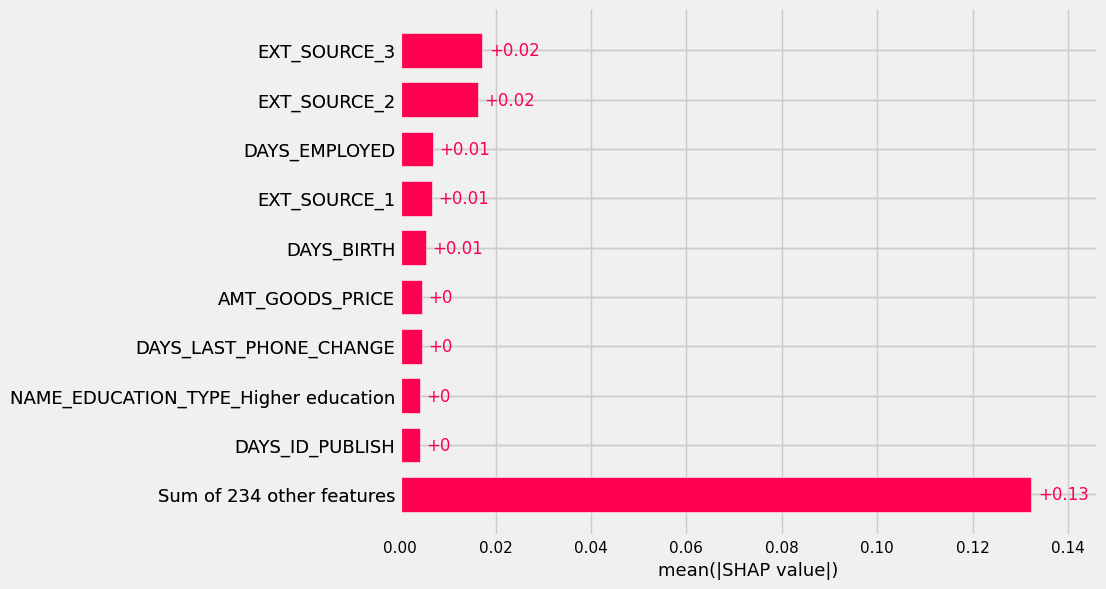

In [ ]:
shap.plots.bar(shap_values[:, :, 1])

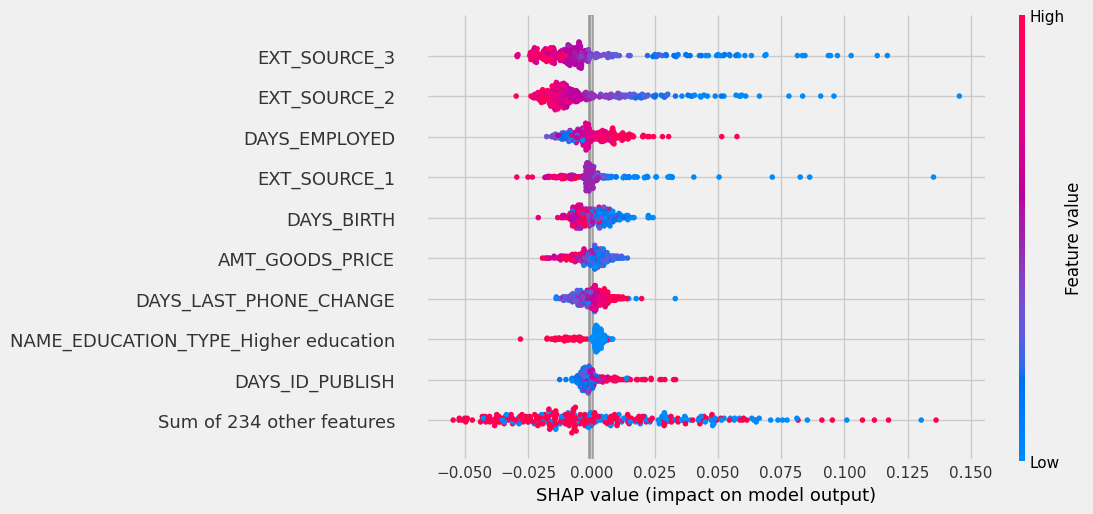

In [ ]:
shap.plots.beeswarm(shap_values[:, :, 1])

### Missing audit

If any of these exterior source is missing, we consider it as a signal of unbanked applicant.

In [ ]:
unbanked_mask = (
    X_val_df["EXT_SOURCE_1"].isna() |
    X_val_df["EXT_SOURCE_2"].isna() |
    X_val_df["EXT_SOURCE_3"].isna()
)

In [ ]:
audit_df["UNBANKED"] = unbanked_mask.values

In [ ]:
audit_df["UNBANKED"].value_counts()

,count
UNBANKED,
True,39545
False,21958


In [ ]:
t = 0.2
audit_df["y_pred"] = (
        audit_df["y_prob"] >= t
    ).astype(int)

unbanked_results = audit_df.groupby(
    "UNBANKED",
    observed=True
).apply(compute_group_metrics)

print(unbanked_results)

                n  true_default_rate  predicted_default_rate   ROC_AUC  \
UNBANKED                                                                 
False     21958.0           0.072274                0.085208  0.717809   
True      39545.0           0.085422                0.076672  0.701541   

          Accuracy  Precision    Recall        F1       FPR       FNR  \
UNBANKED                                                                
False     0.886784   0.259754  0.306238  0.281087  0.067989  0.693762   
True      0.879176   0.269129  0.241563  0.254602  0.061271  0.758437   

               TN      FP      FN     TP  
UNBANKED                                  
False     18986.0  1385.0  1101.0  486.0  
True      33951.0  2216.0  2562.0  816.0  


In [ ]:
unbanked_report = unbanked_results.reset_index()[[
    "UNBANKED",
    "n",
    "true_default_rate",
    "predicted_default_rate",
    "ROC_AUC",
    "FPR",
    "FNR"
]].round(3)
unbanked_report

,UNBANKED,n,true_default_rate,predicted_default_rate,ROC_AUC,FPR,FNR
0,False,21958.0,0.072,0.085,0.718,0.068,0.694
1,True,39545.0,0.085,0.077,0.702,0.061,0.758


In [ ]:
t = 0.08
audit_df["y_pred"] = (
        audit_df["y_prob"] >= t
    ).astype(int)

unbanked_results = audit_df.groupby(
    "UNBANKED",
    observed=True
).apply(compute_group_metrics)

print(unbanked_results)

                n  true_default_rate  predicted_default_rate   ROC_AUC  \
UNBANKED                                                                 
False     21958.0           0.072274                0.484015  0.717809   
True      39545.0           0.085422                0.470502  0.701541   

          Accuracy  Precision    Recall        F1       FPR       FNR  \
UNBANKED                                                                
False     0.552191   0.112062  0.750473  0.195006  0.463257  0.249527   
True      0.568593   0.132323  0.728834  0.223981  0.446374  0.271166   

               TN       FP     FN      TP  
UNBANKED                                   
False     10934.0   9437.0  396.0  1191.0  
True      20023.0  16144.0  916.0  2462.0  


In [ ]:
unbanked_report = unbanked_results.reset_index()[[
    "UNBANKED",
    "n",
    "true_default_rate",
    "predicted_default_rate",
    "ROC_AUC",
    "FPR",
    "FNR"
]].round(3)
unbanked_report

,UNBANKED,n,true_default_rate,predicted_default_rate,ROC_AUC,FPR,FNR
0,False,21958.0,0.072,0.484,0.718,0.463,0.250
1,True,39545.0,0.085,0.471,0.702,0.446,0.271


### Calibration

In [ ]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_val,
    y_val_pred_prob,
    n_bins=10,
    strategy="quantile"
)

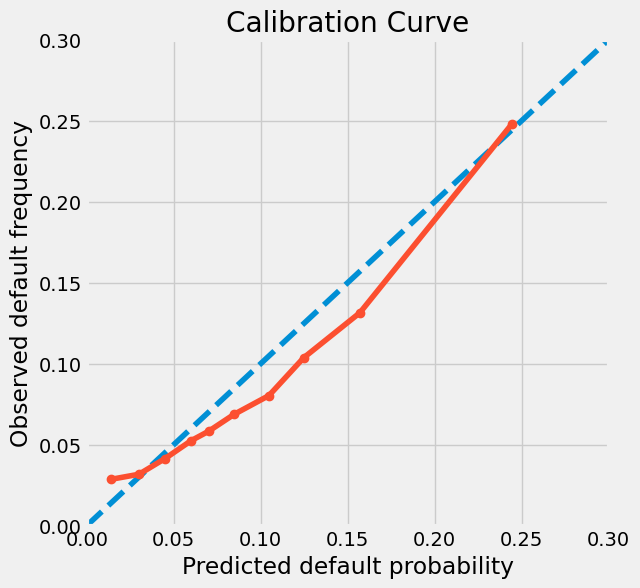

In [ ]:
plt.figure(figsize=(6,6))

# perfect calibration
plt.plot([0,1], [0,1], linestyle='--')

# model calibration
plt.plot(
    prob_pred,
    prob_true,
    marker='o'
)

plt.xlim(0, 0.3)
plt.ylim(0, 0.3)

plt.xlabel("Predicted default probability")
plt.ylabel("Observed default frequency")

plt.title("Calibration Curve")

plt.show()

In [ ]:
gender = X_val_df["CODE_GENDER_F"]

In [ ]:
male_mask = (gender == False)

prob_true_m, prob_pred_m = calibration_curve(
    y_val[male_mask],
    y_val_pred_prob[male_mask],
    n_bins=10,
    strategy="quantile"
)

female_mask = (gender == True)

prob_true_f, prob_pred_f = calibration_curve(
    y_val[female_mask],
    y_val_pred_prob[female_mask],
    n_bins=10,
    strategy="quantile"
)

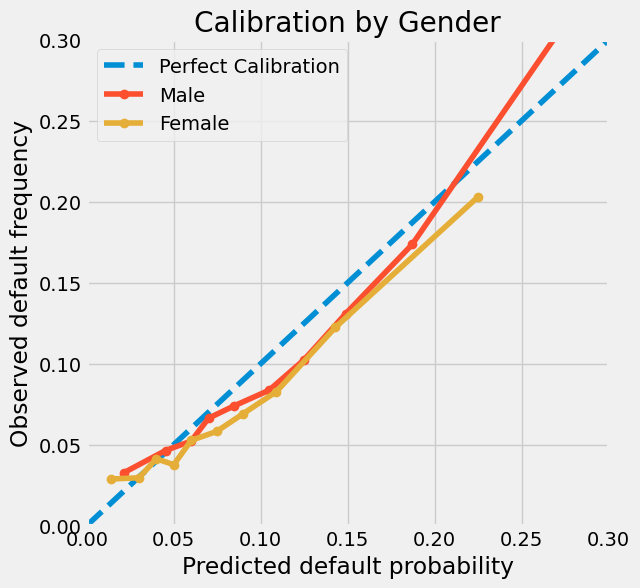

In [ ]:
plt.figure(figsize=(6,6))

plt.plot([0,1],[0,1],'--', label="Perfect Calibration")

plt.plot(
    prob_pred_m,
    prob_true_m,
    marker='o',
    label='Male'
)

plt.plot(
    prob_pred_f,
    prob_true_f,
    marker='o',
    label='Female'
)

plt.xlim(0, 0.3)
plt.ylim(0, 0.3)

plt.xlabel("Predicted default probability")
plt.ylabel("Observed default frequency")

plt.title("Calibration by Gender")

plt.legend()

plt.show()

In [ ]:
non_unbanked_mask = (audit_df["UNBANKED"] == False)

prob_true_f, prob_pred_f = calibration_curve(
    y_val[non_unbanked_mask],
    y_val_pred_prob[non_unbanked_mask],
    n_bins=10,
    strategy="quantile"
)

unbanked_mask = (audit_df["UNBANKED"] == True)

prob_true_t, prob_pred_t = calibration_curve(
    y_val[unbanked_mask],
    y_val_pred_prob[unbanked_mask],
    n_bins=10,
    strategy="quantile"
)

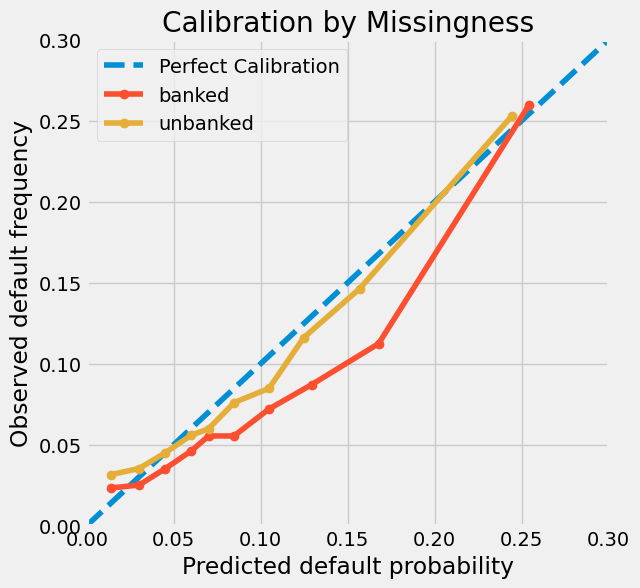

In [ ]:
plt.figure(figsize=(6,6))

plt.plot([0,1],[0,1],'--', label="Perfect Calibration")

plt.plot(
    prob_pred_f,
    prob_true_f,
    marker='o',
    label='banked'
)

plt.plot(
    prob_pred_t,
    prob_true_t,
    marker='o',
    label='unbanked'
)

plt.xlim(0, 0.3)
plt.ylim(0, 0.3)

plt.xlabel("Predicted default probability")
plt.ylabel("Observed default frequency")

plt.title("Calibration by Missingness")

plt.legend()

plt.show()